In [1]:
# =========================================================
# Handwritten Digit Recognition using CNN (MNIST)
# Deep Learning Project
# =========================================================

# =========================================================
# 1. Import Libraries
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import datasets, layers, models, callbacks
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


In [2]:
# =========================================================
# 2. Load MNIST Dataset
# =========================================================

(x_train_raw, y_train), (x_test_raw, y_test) = datasets.mnist.load_data()

print("\nDataset Loaded Successfully")
print("Training Images Shape:", x_train_raw.shape)
print("Testing Images Shape :", x_test_raw.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Dataset Loaded Successfully
Training Images Shape: (60000, 28, 28)
Testing Images Shape : (10000, 28, 28)


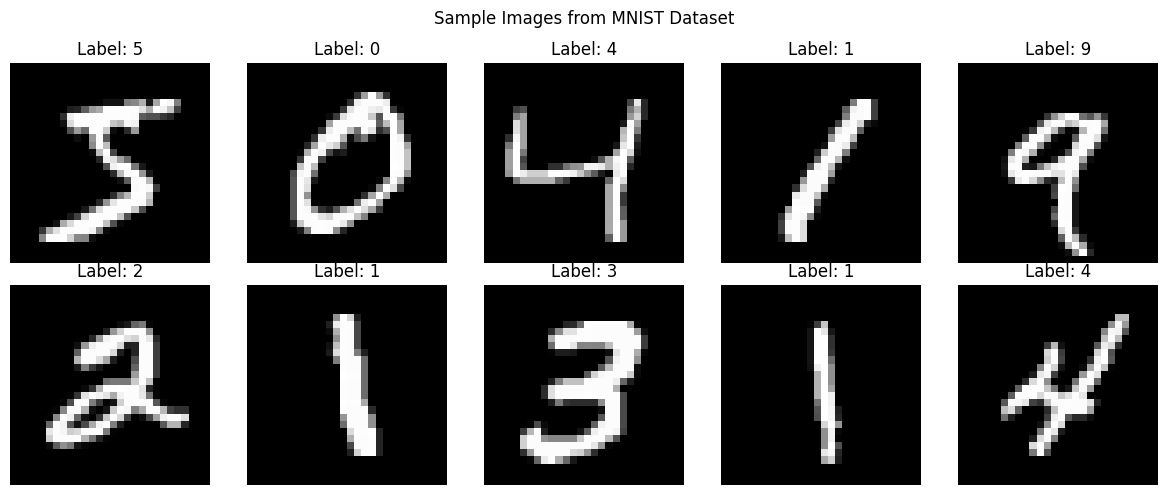

In [3]:
# =========================================================
# 3. Display Sample Images
# =========================================================

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.suptitle("Sample Images from MNIST Dataset")
plt.tight_layout()
plt.show()

In [4]:
# =========================================================
# 4. Preprocessing
# =========================================================

# Normalize images (0-255 -> 0-1)
x_train = x_train_raw / 255.0
x_test = x_test_raw / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("\nAfter Preprocessing")
print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)



After Preprocessing
x_train shape: (60000, 28, 28, 1)
x_test shape : (10000, 28, 28, 1)


In [5]:
# =========================================================
# 5. Data Augmentation
# =========================================================

datagen = ImageDataGenerator(
    rotation_range=8,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train)


In [6]:
# =========================================================
# 6. Build CNN Model Function
# =========================================================

def build_model():

    model = models.Sequential()

    # ---------------------------
    # First CNN Block
    # ---------------------------

    model.add(layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(28,28,1)
    ))

    model.add(layers.BatchNormalization())

    model.add(layers.MaxPooling2D((2,2)))

    # ---------------------------
    # Second CNN Block
    # ---------------------------

    model.add(layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ))

    model.add(layers.BatchNormalization())

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Dropout(0.25))

    # ---------------------------
    # Third CNN Block
    # ---------------------------

    model.add(layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ))

    model.add(layers.BatchNormalization())

    model.add(layers.Dropout(0.25))

    # ---------------------------
    # Flatten Layer
    # ---------------------------

    model.add(layers.Flatten())

    # ---------------------------
    # Dense Hidden Layer
    # ---------------------------

    model.add(layers.Dense(
        128,
        activation='relu'
    ))

    model.add(layers.BatchNormalization())

    model.add(layers.Dropout(0.5))

    # ---------------------------
    # Output Layer
    # ---------------------------

    model.add(layers.Dense(
        10,
        activation='softmax'
    ))

    return model


In [9]:
# =========================================================
# 7. Training Function
# =========================================================

def train_model(model, optimizer_name, optimizer):

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3
    )

    print(f"\nTraining Model using {optimizer_name}")

    # Train model
    history = model.fit(
        datagen.flow(x_train, y_train, batch_size=64),
        epochs=25,
        validation_data=(x_test, y_test),
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Evaluate model
    loss, accuracy = model.evaluate(x_test, y_test)

    print(f"\n{optimizer_name} Results")
    print("Accuracy:", accuracy)
    print("Loss:", loss)

    return history, loss, accuracy


In [10]:
# =========================================================
# 8. Experiment 1 - Adam Optimizer
# =========================================================

model_adam = build_model()

history_adam, loss_adam, acc_adam = train_model(
    model_adam,
    "Adam",
    Adam(learning_rate=0.001)
)


Training Model using Adam
Epoch 1/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 31ms/step - accuracy: 0.9108 - loss: 0.2926 - val_accuracy: 0.9801 - val_loss: 0.0604 - learning_rate: 0.0010
Epoch 2/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9667 - loss: 0.1062 - val_accuracy: 0.9812 - val_loss: 0.0612 - learning_rate: 0.0010
Epoch 3/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9746 - loss: 0.0836 - val_accuracy: 0.9878 - val_loss: 0.0351 - learning_rate: 0.0010
Epoch 4/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9766 - loss: 0.0756 - val_accuracy: 0.9892 - val_loss: 0.0334 - learning_rate: 0.0010
Epoch 5/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9791 - loss: 0.0671 - val_accuracy: 0.9898 - val_loss: 0.0301 - learning_rate: 0.0010
Epoch 6/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9814 - loss: 0.0610 - val_accuracy: 0.9922 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 7/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/

In [11]:
# =========================================================
# 9. Experiment 2 - SGD Optimizer
# =========================================================

model_sgd = build_model()

history_sgd, loss_sgd, acc_sgd = train_model(
    model_sgd,
    "SGD",
    SGD(learning_rate=0.01, momentum=0.9)
)


Training Model using SGD
Epoch 1/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - accuracy: 0.9093 - loss: 0.2962 - val_accuracy: 0.9787 - val_loss: 0.0703 - learning_rate: 0.0100
Epoch 2/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9642 - loss: 0.1182 - val_accuracy: 0.9853 - val_loss: 0.0491 - learning_rate: 0.0100
Epoch 3/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9713 - loss: 0.0939 - val_accuracy: 0.9912 - val_loss: 0.0282 - learning_rate: 0.0100
Epoch 4/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9756 - loss: 0.0799 - val_accuracy: 0.9910 - val_loss: 0.0277 - learning_rate: 0.0100
Epoch 5/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9777 - loss: 0.0726 - val_accuracy: 0.9834 - val_loss: 0.0480 - learning_rate: 0.0100
Epoch 6/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9806 - loss: 0.0639 - val_accuracy: 0.9937 - val_loss: 0.0201 - learning_rate: 0.0100
Epoch 7/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/s

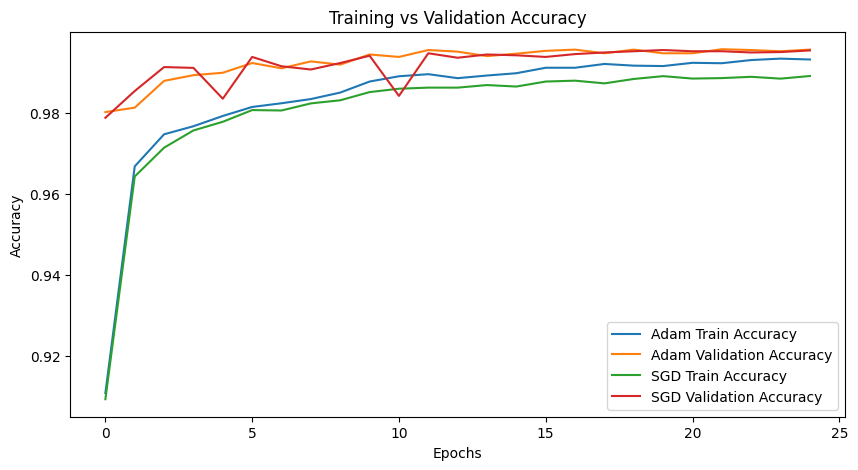

In [12]:
# =========================================================
# 10. Plot Accuracy Curves
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(history_adam.history['accuracy'], label='Adam Train Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Adam Validation Accuracy')

plt.plot(history_sgd.history['accuracy'], label='SGD Train Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='SGD Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

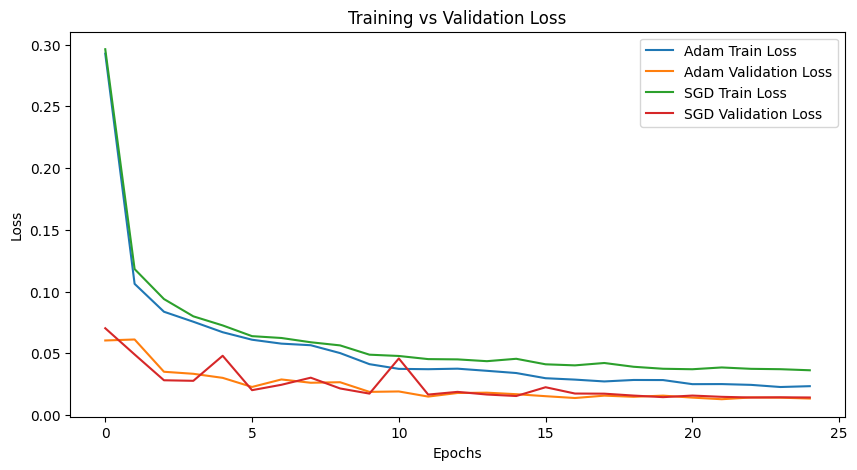

In [13]:
# =========================================================
# 11. Plot Loss Curves
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(history_adam.history['loss'], label='Adam Train Loss')
plt.plot(history_adam.history['val_loss'], label='Adam Validation Loss')

plt.plot(history_sgd.history['loss'], label='SGD Train Loss')
plt.plot(history_sgd.history['val_loss'], label='SGD Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()


In [14]:
# =========================================================
# 12. Select Best Model
# =========================================================

if acc_adam > acc_sgd:
    best_model = model_adam
    best_name = "Adam"
else:
    best_model = model_sgd
    best_name = "SGD"

print("\nBest Model:", best_name)



Best Model: Adam


In [15]:
# =========================================================
# 13. Predictions
# =========================================================

y_pred = np.argmax(best_model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


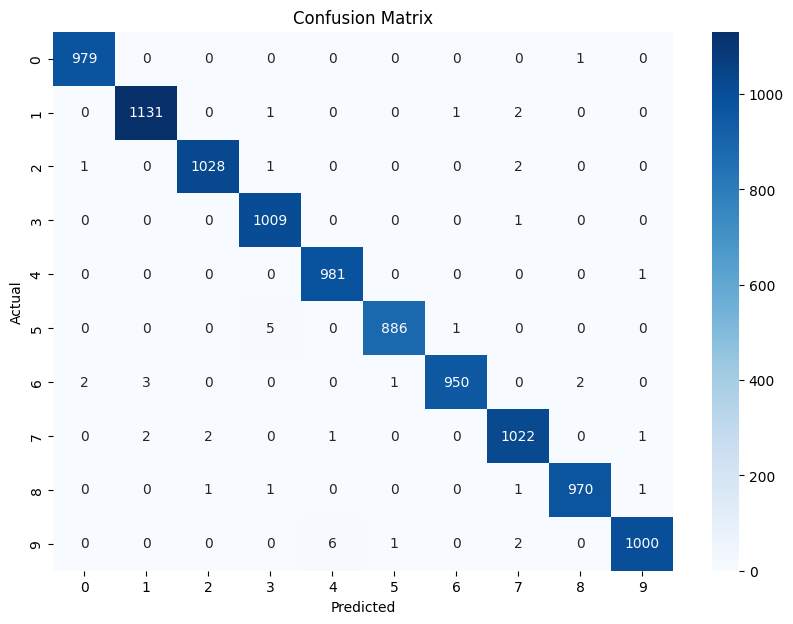

In [16]:
# =========================================================
# 14. Confusion Matrix
# =========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
# =========================================================
# 15. Classification Report
# =========================================================

print("\nClassification Report\n")

print(classification_report(
    y_test,
    y_pred
))



Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       1.00      0.99      1.00       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      1.00      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



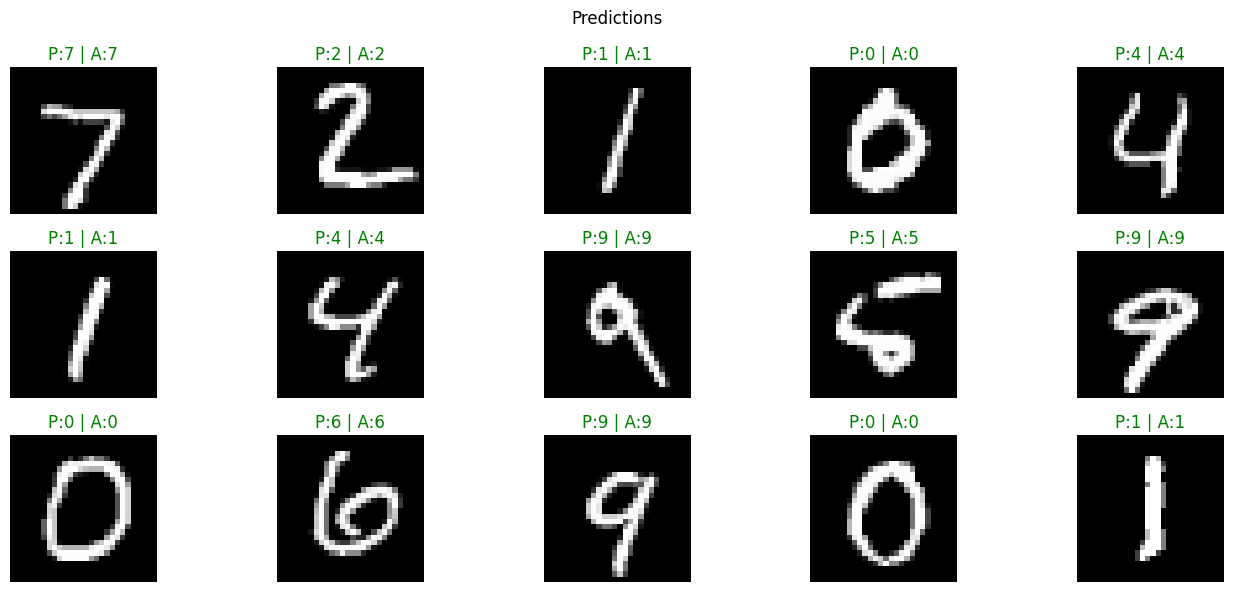

In [18]:
# =========================================================
# 16. Visualize Predictions
# =========================================================

plt.figure(figsize=(14,6))

for i in range(15):

    plt.subplot(3,5,i+1)

    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    predicted = y_pred[i]
    actual = y_test[i]

    color = 'green' if predicted == actual else 'red'

    plt.title(
        f"P:{predicted} | A:{actual}",
        color=color
    )

    plt.axis('off')

plt.suptitle("Predictions")
plt.tight_layout()

plt.show()

In [19]:
# =========================================================
# 17. Final Comparison Table
# =========================================================

print("\n======================================")
print("FINAL RESULTS COMPARISON")
print("======================================")

print("\nExperiment 1 - Adam")
print("Accuracy:", round(acc_adam*100,2), "%")
print("Loss:", round(loss_adam,4))

print("\nExperiment 2 - SGD")
print("Accuracy:", round(acc_sgd*100,2), "%")
print("Loss:", round(loss_sgd,4))


FINAL RESULTS COMPARISON

Experiment 1 - Adam
Accuracy: 99.56 %
Loss: 0.0128

Experiment 2 - SGD
Accuracy: 99.48 %
Loss: 0.0142


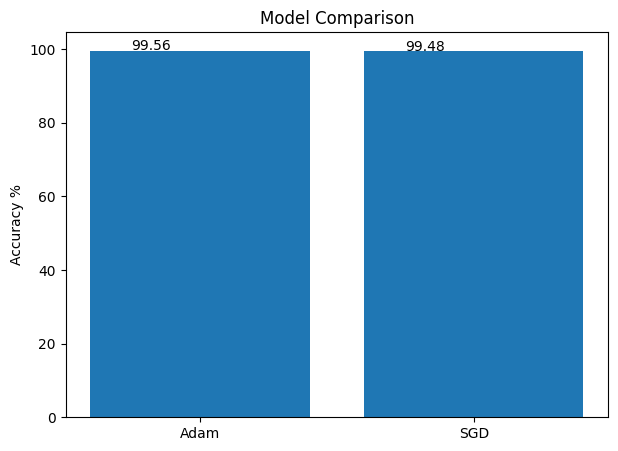

In [20]:
# =========================================================
# 18. Accuracy Comparison Chart
# =========================================================

models_names = ['Adam', 'SGD']
accuracies = [acc_adam*100, acc_sgd*100]

plt.figure(figsize=(7,5))

bars = plt.bar(models_names, accuracies)

plt.ylabel("Accuracy %")
plt.title("Model Comparison")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + 0.15,
        yval + 0.1,
        round(yval,2)
    )

plt.show()

In [21]:
# =========================================================
# 19. Final Summary
# =========================================================

winner = "Adam" if acc_adam > acc_sgd else "SGD"

print("\n======================================")
print("PROJECT SUMMARY")
print("======================================")

print("Dataset  : MNIST")
print("Task     : Image Classification")
print("Model    : CNN")

print("\nAdam Accuracy :", round(acc_adam*100,2), "%")
print("SGD Accuracy  :", round(acc_sgd*100,2), "%")

print("\nBest Optimizer :", winner)

print("\nProject Completed Successfully")


PROJECT SUMMARY
Dataset  : MNIST
Task     : Image Classification
Model    : CNN

Adam Accuracy : 99.56 %
SGD Accuracy  : 99.48 %

Best Optimizer : Adam

Project Completed Successfully
